In [3]:
# Install required libraries
#pip install -q torch transformers accelerate sympy matplotlib seaborn

SyntaxError: invalid syntax (655256298.py, line 2)

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

## Part 1: Reward Engine

The reward function in DeepSeek-R1-Zero is fully deterministic and rule-based, following:

$$
R_{\text{rule}} = R_{\text{acc}} + R_{\text{fmt}}
$$

To prevent zero-gradient deadlocks in small models, the engine uses a four-tier reward hierarchy:

```text
Generated Completion
├── Format Verification
│   ├── Check <think>...</think>
│   ├── Check <answer>...</answer>
│   └── Score: R_fmt in [0.0, 0.1]
└── Accuracy Verification
    ├── Extract answer string
    ├── Parse with SymPy / Regex
    └── Score: R_acc in [0.0, 1.0]
```

### Reward details

- Strict format match: $R_{\text{fmt}} = 0.1$
- Partial or soft format credit: $R_{\text{fmt}} \in (0.0, 0.1)$
- Accuracy match via SymPy: $R_{\text{acc}} = 1.0$
- Fallback raw string match if parsing fails


In [9]:
"""
reward_engine.py
----------------

Deterministic, rule-based reward evaluator for DeepSeek-R1-Zero arithmetic tasks.
Evaluates both structural formatting (R_fmt) and mathematical correctness (R_acc).
"""

import re
import sympy
from typing import Dict, Any, Union


class R1ZeroRewardEngine:
    """
    Rule-based reward engine implementing R_rule = R_acc + R_fmt.
    Includes soft-format credit to prevent zero-variance gradient deadlocks 
    during early training of small models.
    """
    def __init__(self, format_weight: float = 0.1):
        self.format_weight = format_weight
        
        # Regex for strict end-to-end tag validation
        self.strict_format_regex = re.compile(
            r"^\s*<think>(.*?)</think>\s*<answer>(.*?)</answer>\s*$", 
            re.DOTALL
        )

    def evaluate_math_correctness(self, pred_str: str, target_str: str) -> bool:
        """
        Uses SymPy to check mathematical equivalence between prediction and target.
        Falls back to normalized string comparison if parsing fails.
        """
        clean_pred = pred_str.strip().replace(",", "")
        clean_target = target_str.strip().replace(",", "")

        if not clean_pred:
            return False

        try:
            pred_expr = sympy.parse_expr(clean_pred)
            target_expr = sympy.parse_expr(clean_target)
            return sympy.simplify(pred_expr - target_expr) == 0
        except Exception:
            # Fallback to direct string matching
            return clean_pred == clean_target

    def extract_answer_content(self, text: str) -> str:
        """
        Extracts answer content enclosed within <answer>...</answer> tags.
        If tags are missing, attempts to extract the last non-empty line.
        """
        answer_match = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL)
        if answer_match:
            return answer_match.group(1).strip()
        
        # Fallback extraction if tags are partially formed
        if "<answer>" in text:
            return text.split("<answer>")[-1].replace("</answer>", "").strip()
            
        return text.strip()

    def compute_format_reward(self, text: str) -> float:
        """
        Calculates R_fmt.
        Strict match: +0.1
        Partial matches (<think> or <answer> tags present): +0.02 to +0.05
        """
        if self.strict_format_regex.match(text):
            return self.format_weight
        
        # Soft format credit for small models in early RL steps
        partial_score = 0.0
        if "<think>" in text:
            partial_score += 0.025
        if "</think>" in text:
            partial_score += 0.025
        if "<answer>" in text:
            partial_score += 0.025
        if "</answer>" in text:
            partial_score += 0.025
            
        return min(partial_score, self.format_weight)

    def compute_reward(self, completion_text: str, ground_truth: str) -> Dict[str, Any]:
        """
        Main evaluation entry point.
        Returns total_reward, r_acc, r_fmt, and metadata for logging.
        """
        r_fmt = self.compute_format_reward(completion_text)
        
        # Extract answer and check accuracy
        extracted_ans = self.extract_answer_content(completion_text)
        is_correct = self.evaluate_math_correctness(extracted_ans, ground_truth)
        
        # Accuracy reward is only awarded if answer is mathematically correct
        r_acc = 1.0 if is_correct else 0.0
        
        total_reward = r_acc + r_fmt
        
        return {
            "total_reward": total_reward,
            "r_acc": r_acc,
            "r_fmt": r_fmt,
            "is_correct": is_correct,
            "extracted_answer": extracted_ans
        }


# =====================================================================
# Standalone Unit Test Suite
# =====================================================================
if __name__ == "__main__":
    print("=== Running Unit Test Suite for reward_engine.py ===")
    verifier = R1ZeroRewardEngine(format_weight=0.1)

    test_cases = [
        {
            "name": "Perfect Output (Correct + Strict Format)",
            "input": "<think> 14 * 3 = 42, 42 - 12 = 30 </think> <answer> 30 </answer>",
            "truth": "30",
            "expected_reward": 1.1,
            "expected_correct": True
        },
        {
            "name": "SymPy Equivalence (Fraction vs Decimal)",
            "input": "<think> 1 / 2 </think> <answer> 0.5 </answer>",
            "truth": "1/2",
            "expected_reward": 1.1,
            "expected_correct": True
        },
        {
            "name": "Wrong Answer + Strict Format",
            "input": "<think> 14 * 3 = 42 </think> <answer> 99 </answer>",
            "truth": "30",
            "expected_reward": 0.1,
            "expected_correct": False
        },
        {
            "name": "Partial Tags (Soft Format Credit)",
            "input": "<think> 14 * 3 = 42, Answer is 30",
            "truth": "30",
            "expected_reward": 0.025,
            "expected_correct": False # No <answer> tag
        },
        {
            "name": "No Tags At All",
            "input": "The result is 30",
            "truth": "30",
            "expected_reward": 0.0,
            "expected_correct": False
        }
    ]

    all_passed = True
    for idx, tc in enumerate(test_cases, 1):
        res = verifier.compute_reward(tc["input"], tc["truth"])
        passed = (abs(res["total_reward"] - tc["expected_reward"]) < 1e-5) and (res["is_correct"] == tc["expected_correct"])
        status = "PASSED" if passed else "FAILED"
        if not passed:
            all_passed = False
        print(f"Test {idx} [{tc['name']}]: {status}")
        print(f"  Result -> Reward: {res['total_reward']:.3f} | Correct: {res['is_correct']} | Extracted: '{res['extracted_answer']}'")

    print("\nUnit Test Suite Summary:", "ALL TESTS PASSED!" if all_passed else "SOME TESTS FAILED!")

=== Running Unit Test Suite for reward_engine.py ===
Test 1 [Perfect Output (Correct + Strict Format)]: PASSED
  Result -> Reward: 1.100 | Correct: True | Extracted: '30'
Test 2 [SymPy Equivalence (Fraction vs Decimal)]: PASSED
  Result -> Reward: 1.100 | Correct: True | Extracted: '0.5'
Test 3 [Wrong Answer + Strict Format]: PASSED
  Result -> Reward: 0.100 | Correct: False | Extracted: '99'
Test 4 [Partial Tags (Soft Format Credit)]: PASSED
  Result -> Reward: 0.025 | Correct: False | Extracted: '<think> 14 * 3 = 42, Answer is 30'
Test 5 [No Tags At All]: PASSED
  Result -> Reward: 0.000 | Correct: False | Extracted: 'The result is 30'

Unit Test Suite Summary: ALL TESTS PASSED!


## Dataset

In the DeepSeek-R1 paper, training requires framing prompts with a strict conversational structure that instructs the model to place its reasoning inside `<think>...</think>` tags and its final solution inside `<answer>...</answer>` tags.

For the arithmetic tasks, the dataset module will:

- programmatically generate multi-step arithmetic problems,
- provide mathematical ground truths,
- wrap each problem in the R1-Zero prompt template,
- and prime the generation head by appending `<think>` so the model begins reasoning immediately during rollouts.


In [10]:
"""
dataset.py
----------------
Synthetic arithmetic dataset generator and prompt formatter following 
the DeepSeek-R1-Zero conversational template (Table 1 in deepseekRL.pdf).
"""

import random
import torch
from torch.utils.data import Dataset


class SyntheticArithmeticDataset(Dataset):
    """
    Generates multi-step arithmetic expressions and formats them into 
    the R1-Zero prompt template (Table 1):
    "A conversation between User and Assistant. The user asks a question, 
    and the Assistant solves it. The assistant first thinks about the reasoning 
    process in the mind and then provides the user with the answer. 
    The reasoning process and answer are enclosed within <think>...</think> 
    and <answer>...</answer> tags..."
    """
    def __init__(self, num_samples: int = 500, seed: int = 42):
        random.seed(seed)
        self.data = []
        
        for _ in range(num_samples):
            # Generate 2-step arithmetic problem: A * B +/- C
            a = random.randint(2, 12)
            b = random.randint(2, 10)
            c = random.randint(1, 25)
            op = random.choice(["+", "-"])
            
            if op == "+":
                ans = a * b + c
            else:
                ans = a * b - c
                
            prompt_expr = f"{a}*{b}{op}{c}="
            target_ans = str(ans)
            
            # Format according to DeepSeek-R1-Zero prompt template (Table 1)[cite: 1]
            formatted_prompt = (
                "A conversation between User and Assistant. The user asks a question, "
                "and the Assistant solves it. The assistant first thinks about the reasoning "
                "process in the mind and then provides the user with the answer. "
                "The reasoning process and answer are enclosed within <think>...</think> "
                "and <answer>...</answer> tags, respectively. "
                f"User: Solve {prompt_expr} Assistant: <think>"
            )
            
            self.data.append({
                "prompt": formatted_prompt,
                "expression": prompt_expr,
                "ground_truth": target_ans
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# =====================================================================
# Standalone Unit Test Suite
# =====================================================================
if __name__ == "__main__":
    print("=== Running Unit Test Suite for dataset.py ===")
    dataset = SyntheticArithmeticDataset(num_samples=3)
    
    for i in range(len(dataset)):
        sample = dataset[i]
        print(f"\nSample {i+1}:")
        print(f"  Expression:   {sample['expression']}")
        print(f"  Ground Truth: {sample['ground_truth']}")
        print(f"  Full Prompt:\n{sample['prompt']}")
        
    print("\nDataset Module Successfully Verified!")

=== Running Unit Test Suite for dataset.py ===

Sample 1:
  Expression:   12*3-1=
  Ground Truth: 35
  Full Prompt:
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning process and answer are enclosed within <think>...</think> and <answer>...</answer> tags, respectively. User: Solve 12*3-1= Assistant: <think>

Sample 2:
  Expression:   5*5+5=
  Ground Truth: 30
  Full Prompt:
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning process and answer are enclosed within <think>...</think> and <answer>...</answer> tags, respectively. User: Solve 5*5+5= Assistant: <think>

Sample 3:
  Expression:   12*10-3=
  Ground Truth: 117
  Full Prompt:
A conversation b

## Loss

### Mathematical review and paper alignment

- Group advantage calculation ($A_i$, Equation 3):

$$
A_i = \frac{r_i - \text{mean}(\mathbf{r})}{\text{std}(\mathbf{r}) + \epsilon}
$$

- If $\text{std}(\mathbf{r}) = 0$, then $A_i$ is set to $0.0$ for the full group to avoid division by zero.

- Unbiased token-level KL divergence ($D_{\text{KL}}$, Equation 2):

$$
D_{\text{KL}}(\pi_\theta \;\|\|\; \pi_{\text{ref}})
=
\frac{\pi_{\text{ref}}(y_t \mid x, y_{<t})}{\pi_\theta(y_t \mid x, y_{<t})}
-
\log\frac{\pi_{\text{ref}}(y_t \mid x, y_{<t})}{\pi_\theta(y_t \mid x, y_{<t})}
- 1
$$

- Using log-probabilities directly, where $\Delta = \log \pi_{\text{ref}}(y_t) - \log \pi_\theta(y_t)$:

$$
D_{\text{KL}} = \exp(\Delta) - \Delta - 1
$$

- Clipped surrogate loss ($\mathcal{J}_{\text{GRPO}}$, Equation 1):

$$
\mathcal{L}_{\text{surr}} = \min \left( r_{i,t}(\theta) A_i, \; \text{clip}(r_{i,t}(\theta), 1-\epsilon, 1+\epsilon) A_i \right)
$$

$$
\mathcal{L}_{\text{total}} = -\frac{1}{G \cdot T} \sum_{i=1}^{G} \sum_{t=1}^{T} \left( \mathcal{L}_{\text{surr}, i, t} - \beta \cdot D_{\text{KL}, i, t} \right)
$$


In [11]:
"""
grpo_loss.py
------------
Pure PyTorch implementation of Group Relative Policy Optimization (GRPO) loss functions,
Group Advantage normalization, and Schulman's unbiased token-level KL divergence.
(Equations 1, 2, and 3 in deepseekRL.pdf).
"""

import torch
import torch.nn as nn
from typing import Tuple, Dict, Any


def compute_group_advantages(rewards: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Computes intra-group relative advantages (Equation 3).
    rewards shape: [group_size]
    returns shape: [group_size]
    """
    mean_r = torch.mean(rewards)
    std_r = torch.std(rewards, unbiased=False)
    
    # Handle zero variance edge case (e.g., all responses get 0 reward)
    if std_r < eps:
        return torch.zeros_like(rewards)
        
    advantages = (rewards - mean_r) / (std_r + eps)
    return advantages


def compute_unbiased_kl(log_p_curr: torch.Tensor, log_p_ref: torch.Tensor) -> torch.Tensor:
    """
    Schulman's unbiased token-level KL estimator (Equation 2):
    KL = (pi_ref / pi_theta) - log(pi_ref / pi_theta) - 1
    
    log_p_curr shape: [batch_size, seq_len]
    log_p_ref shape:  [batch_size, seq_len]
    returns shape:     [batch_size, seq_len]
    """
    log_ratio = log_p_ref - log_p_curr
    kl = torch.exp(log_ratio) - log_ratio - 1.0
    return kl


def compute_grpo_loss(
    log_probs_curr: torch.Tensor,  # [G, T] - current policy log-probabilities
    log_probs_old: torch.Tensor,   # [G, T] - rollout policy log-probabilities (detached)
    log_probs_ref: torch.Tensor,   # [G, T] - reference policy log-probabilities (detached)
    advantages: torch.Tensor,      # [G]    - scalar advantages
    completion_mask: torch.Tensor, # [G, T] - boolean/float mask indicating non-padding completion tokens
    clip_eps: float = 0.2,         # PPO/GRPO clipping threshold
    beta_kl: float = 0.001         # KL penalty coefficient
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """
    Calculates masked GRPO surrogate loss with unbiased token KL regularization (Equation 1).
    """
    group_size, seq_len = log_probs_curr.shape
    
    # Expand advantages across sequence dimension: [G] -> [G, 1]
    adv_expanded = advantages.unsqueeze(-1)
    
    # 1. Probability ratio r_t(theta) = exp(log_p_curr - log_p_old)
    log_ratios = log_probs_curr - log_probs_old
    ratios = torch.exp(log_ratios)
    
    # 2. PPO-style clipped surrogate objective
    surr1 = ratios * adv_expanded
    surr2 = torch.clamp(ratios, 1.0 - clip_eps, 1.0 + clip_eps) * adv_expanded
    policy_surrogate = torch.min(surr1, surr2) # [G, T]
    
    # 3. Unbiased token-level KL penalty
    kl_penalty = compute_unbiased_kl(log_probs_curr, log_probs_ref) # [G, T]
    
    # 4. Net per-token objective (we want to maximize policy_surrogate - beta * KL)
    # Loss is the negative of the objective
    token_loss = -(policy_surrogate - beta_kl * kl_penalty) # [G, T]
    
    # Apply completion mask to ignore padding tokens
    masked_loss = token_loss * completion_mask
    num_active_tokens = completion_mask.sum().clamp(min=1.0)
    
    total_loss = masked_loss.sum() / num_active_tokens
    
    # Metrics for monitoring
    with torch.no_grad():
        mean_kl = (kl_penalty * completion_mask).sum() / num_active_tokens
        mean_ratio = (ratios * completion_mask).sum() / num_active_tokens
        clip_fraction = (((ratios - 1.0).abs() > clip_eps).float() * completion_mask).sum() / num_active_tokens

    metrics = {
        "grpo_loss": total_loss.item(),
        "mean_kl": mean_kl.item(),
        "mean_ratio": mean_ratio.item(),
        "clip_fraction": clip_fraction.item()
    }

    return total_loss, metrics


# =====================================================================
# Standalone Unit Test Suite
# =====================================================================
if __name__ == "__main__":
    print("=== Running Unit Test Suite for grpo_loss.py ===")
    torch.manual_seed(42)

    G = 4  # Group size
    T = 6  # Sequence length

    # Test 1: Advantage Normalization
    rewards = torch.tensor([0.0, 1.1, 0.0, 0.1])
    advs = compute_group_advantages(rewards)
    print(f"Test 1 [Advantage Normalization]:")
    print(f"  Rewards:    {rewards.tolist()}")
    print(f"  Advantages: {[round(a, 3) for a in advs.tolist()]}")
    assert advs.shape == (G,), "Advantage shape mismatch"

    # Test 2: Advantage Zero-Variance Edge Case
    zero_rewards = torch.tensor([0.0, 0.0, 0.0, 0.0])
    zero_advs = compute_group_advantages(zero_rewards)
    print(f"Test 2 [Zero Variance Check]:")
    print(f"  Zero Advantages: {zero_advs.tolist()}")
    assert (zero_advs == 0.0).all(), "Zero variance advantages failed"

    # Test 3: Loss Backpropagation and Masking
    log_p_curr = torch.randn(G, T, requires_grad=True)
    log_p_old = log_p_curr.detach() - 0.02
    log_p_ref = log_p_curr.detach() - 0.05
    mask = torch.tensor([[1, 1, 1, 1, 0, 0],
                          [1, 1, 1, 1, 1, 1],
                          [1, 1, 1, 0, 0, 0],
                          [1, 1, 1, 1, 1, 0]], dtype=torch.float32)

    loss, metrics = compute_grpo_loss(
        log_probs_curr=log_p_curr,
        log_probs_old=log_p_old,
        log_probs_ref=log_p_ref,
        advantages=advs,
        completion_mask=mask
    )

    loss.backward()

    print(f"Test 3 [Loss Backpropagation]:")
    print(f"  Calculated GRPO Loss: {metrics['grpo_loss']:.6f}")
    print(f"  Mean KL Divergence:  {metrics['mean_kl']:.6f}")
    print(f"  Clipping Fraction:   {metrics['clip_fraction']:.2%}")
    print(f"  Gradients Computed:  {log_p_curr.grad is not None and not torch.isnan(log_p_curr.grad).any()}")
    
    assert log_p_curr.grad is not None, "Backward pass failed to compute gradients"
    print("\nGRPO Loss Module Successfully Verified!")

=== Running Unit Test Suite for grpo_loss.py ===
Test 1 [Advantage Normalization]:
  Rewards:    [0.0, 1.100000023841858, 0.0, 0.10000000149011612]
  Advantages: [-0.647, 1.725, -0.647, -0.431]
Test 2 [Zero Variance Check]:
  Zero Advantages: [0.0, 0.0, 0.0, 0.0]
Test 3 [Loss Backpropagation]:
  Calculated GRPO Loss: -0.207798
  Mean KL Divergence:  0.001229
  Clipping Fraction:   0.00%
  Gradients Computed:  True

GRPO Loss Module Successfully Verified!


In [12]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import seaborn as sns

# Import our custom modules
# from reward_engine import R1ZeroRewardEngine
# from dataset import SyntheticArithmeticDataset
# from grpo_loss import compute_group_advantages, compute_grpo_loss

# Device configuration (Google Colab T4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: Tesla T4


## Loading the model

This section loads the tokenizer and the policy/reference language models used throughout the training and rollout pipeline.

In [13]:
MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"

print(f"Loading Tokenizer & Policy Model: {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Ensure proper pad_token configuration
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load Trainable Policy Model
policy_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32 # FP32 is fast on 135M and prevents FP16 underflow/overflow
).to(device)

# Ensure model config reflects tokenizer pad_token_id
policy_model.config.pad_token_id = tokenizer.pad_token_id

# Load Frozen Reference Model
print("Loading Frozen Reference Model...")
ref_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32
).to(device)

ref_model.config.pad_token_id = tokenizer.pad_token_id
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad = False

print(f"Models initialized! Vocab Size: {tokenizer.vocab_size}")

Loading Tokenizer & Policy Model: HuggingFaceTB/SmolLM2-135M-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading Frozen Reference Model...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Models initialized! Vocab Size: 49152


## Training loop overview

This cell runs the core GRPO training loop from the DeepSeek-R1-style pipeline.

It performs the following steps:
- samples a group of candidate completions,
- evaluates each rollout with the reward engine,
- computes relative advantages,
- backpropagates the GRPO loss with KL regularization,
- and periodically syncs the reference model.


In [20]:
# =====================================================================
# Cell 3.5: Cold-Start SFT Warmup (Building Structural Tag Prior)
# =====================================================================

print("=== Running Cold-Start SFT Warmup (30 seconds) ===")

# Synthetic Cold-Start Examples
warmup_data = [
    ("User: Solve 4*3+5= Assistant: <think> 4*3=12, 12+5=17 </think> <answer> 17 </answer>", "17"),
    ("User: Solve 6*2-4= Assistant: <think> 6*2=12, 12-4=8 </think> <answer> 8 </answer>", "8"),
    ("User: Solve 5*5+10= Assistant: <think> 5*5=25, 25+10=35 </think> <answer> 35 </answer>", "35"),
    ("User: Solve 8*4-2= Assistant: <think> 8*4=32, 32-2=30 </think> <answer> 30 </answer>", "30"),
    ("User: Solve 3*3+7= Assistant: <think> 3*3=9, 9+7=16 </think> <answer> 16 </answer>", "16"),
]

sft_optimizer = torch.optim.AdamW(policy_model.parameters(), lr=5e-5)
policy_model.train()

for sft_epoch in range(5):
    total_sft_loss = 0.0
    for text, _ in warmup_data:
        inputs = tokenizer(text, return_tensors="pt").to(device)
        targets = inputs["input_ids"].clone()
        
        outputs = policy_model(**inputs, labels=targets)
        loss = outputs.loss
        
        sft_optimizer.zero_grad()
        loss.backward()
        sft_optimizer.step()
        
        total_sft_loss += loss.item()
    
    print(f"SFT Warmup Epoch {sft_epoch+1}/5 | Loss: {total_sft_loss/len(warmup_data):.4f}")

# Sync reference model state after warmup
ref_model.load_state_dict(policy_model.state_dict())
print("Cold-Start SFT Warmup Complete & Reference Model Synced!\n")

=== Running Cold-Start SFT Warmup (30 seconds) ===
SFT Warmup Epoch 1/5 | Loss: 1.8095
SFT Warmup Epoch 2/5 | Loss: 0.5107
SFT Warmup Epoch 3/5 | Loss: 0.2397
SFT Warmup Epoch 4/5 | Loss: 0.1455
SFT Warmup Epoch 5/5 | Loss: 0.1154
Cold-Start SFT Warmup Complete & Reference Model Synced!



In [22]:
# =====================================================================
# Cell 4: Extended & Annealed GRPO Loop (150 Steps)
# =====================================================================

GROUP_SIZE = 8            # G=8 for high-variance advantage estimation
MAX_GEN_TOKENS = 128      # Sufficient budget for CoT + Answer
LEARNING_RATE = 2e-6      # Stable policy learning rate
BETA_KL = 0.001           # Token KL penalty
CLIP_EPS = 0.1            # Tight clip ratio
REF_UPDATE_STEPS = 25     # Update reference policy every 25 steps
EPOCHS = 150              # Extended training run

reward_engine = R1ZeroRewardEngine(format_weight=0.3)
dataset = SyntheticArithmeticDataset(num_samples=200, seed=42)
optimizer = torch.optim.AdamW(policy_model.parameters(), lr=LEARNING_RATE)

history = {
    "step": [],
    "mean_reward": [],
    "grpo_loss": [],
    "mean_kl": [],
    "avg_thinking_length": []
}

print("=== Executing Extended DeepSeek-R1-Zero Loop (150 Steps) ===")

for step in range(EPOCHS):
    batch_item = dataset[step]
    prompt_text = batch_item["prompt"]
    ground_truth = batch_item["ground_truth"]
    
    # 1. Periodic Reference Model Update (pi_ref <- pi_theta)
    if step > 0 and step % REF_UPDATE_STEPS == 0:
        print(f"\n[Pipeline Event] Step {step}: Syncing Reference Model (pi_ref <- pi_theta)...")
        ref_model.load_state_dict(policy_model.state_dict())

    # Tokenize Prompt
    prompt_inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    prompt_ids = prompt_inputs["input_ids"]
    prompt_mask = prompt_inputs["attention_mask"]
    prompt_len = prompt_ids.shape[1]
    
    expanded_prompt_ids = prompt_ids.repeat(GROUP_SIZE, 1)
    expanded_prompt_mask = prompt_mask.repeat(GROUP_SIZE, 1)

    # 2. Rollout G Completions with Exploitation Temperature T=0.7
    policy_model.eval()
    with torch.no_grad():
        generated_outputs = policy_model.generate(
            expanded_prompt_ids,
            attention_mask=expanded_prompt_mask,
            max_new_tokens=MAX_GEN_TOKENS,
            do_sample=True,
            temperature=0.7,  # Annealed temperature for exploitation
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    full_sequences = generated_outputs
    completion_ids = full_sequences[:, prompt_len:]
    gen_len = completion_ids.shape[1]
    
    if gen_len == 0:
        continue

    full_attention_mask = (full_sequences != tokenizer.pad_token_id).long().to(device)
    completion_mask = (completion_ids != tokenizer.pad_token_id).float().to(device)

    # 3. Decode & Evaluate Rewards
    raw_rewards = []
    thinking_lengths = []
    
# In Cell 4, update this block inside the loop:
    for g in range(GROUP_SIZE):
        raw_comp = tokenizer.decode(completion_ids[g], skip_special_tokens=False)
        
        # Prepend prompt's trailing tag so the reward engine sees the complete <think>...</think><answer>...</answer> envelope
        full_text_to_evaluate = "<think>" + raw_comp
        
        eval_res = reward_engine.compute_reward(full_text_to_evaluate, ground_truth)
        raw_rewards.append(eval_res["total_reward"])
        
        if "</think>" in raw_comp:
            think_content = raw_comp.split("</think>")[0]
            thinking_lengths.append(len(think_content.split()))
        elif "<answer>" in raw_comp:
            think_content = raw_comp.split("<answer>")[0]
            thinking_lengths.append(len(think_content.split()))
        else:
            thinking_lengths.append(len(raw_comp.split()))

    rewards_tensor = torch.tensor(raw_rewards, dtype=torch.float32).to(device)
    advantages = compute_group_advantages(rewards_tensor)

    # 4. Compute Log-Probs & Backpropagate
    policy_model.train()
    logits_curr = policy_model(full_sequences, attention_mask=full_attention_mask).logits
    gen_logits_curr = logits_curr[:, prompt_len - 1 : -1, :]
    log_p_curr_all = F.log_softmax(gen_logits_curr, dim=-1)
    
    targets = completion_ids.unsqueeze(-1)
    targets = torch.clamp(targets, min=0, max=log_p_curr_all.shape[-1] - 1)
    
    curr_log_probs = log_p_curr_all.gather(dim=-1, index=targets).squeeze(-1)
    old_log_probs = curr_log_probs.detach()
    
    with torch.no_grad():
        logits_ref = ref_model(full_sequences, attention_mask=full_attention_mask).logits
        gen_logits_ref = logits_ref[:, prompt_len - 1 : -1, :]
        log_p_ref_all = F.log_softmax(gen_logits_ref, dim=-1)
        ref_log_probs = log_p_ref_all.gather(dim=-1, index=targets).squeeze(-1)

    loss, loss_metrics = compute_grpo_loss(
        log_probs_curr=curr_log_probs,
        log_probs_old=old_log_probs,
        log_probs_ref=ref_log_probs,
        advantages=advantages,
        completion_mask=completion_mask,
        clip_eps=CLIP_EPS,
        beta_kl=BETA_KL
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_model.parameters(), max_norm=1.0)
    optimizer.step()

    mean_r = rewards_tensor.mean().item()
    avg_think_len = sum(thinking_lengths) / len(thinking_lengths) if thinking_lengths else 0
    
    history["step"].append(step)
    history["mean_reward"].append(mean_r)
    history["grpo_loss"].append(loss_metrics["grpo_loss"])
    history["mean_kl"].append(loss_metrics["mean_kl"])
    history["avg_thinking_length"].append(avg_think_len)

    if step % 5 == 0 or mean_r > 0.3:
        print(f"Step {step:03d} | Avg Group Reward: {mean_r:.3f} | GRPO Loss: {loss_metrics['grpo_loss']:.6f} | KL: {loss_metrics['mean_kl']:.6f} | Avg Think Len: {avg_think_len:.1f}")

=== Executing Extended DeepSeek-R1-Zero Loop (150 Steps) ===
Step 000 | Avg Group Reward: 0.100 | GRPO Loss: 0.000000 | KL: 0.000164 | Avg Think Len: 1.0
Step 005 | Avg Group Reward: 0.125 | GRPO Loss: 0.000000 | KL: 0.000170 | Avg Think Len: 1.0
Step 010 | Avg Group Reward: 0.150 | GRPO Loss: 0.000003 | KL: 0.003384 | Avg Think Len: 1.0
Step 015 | Avg Group Reward: 0.100 | GRPO Loss: 0.000002 | KL: 0.002245 | Avg Think Len: 1.0
Step 020 | Avg Group Reward: 0.100 | GRPO Loss: 0.000002 | KL: 0.001771 | Avg Think Len: 1.0

[Pipeline Event] Step 25: Syncing Reference Model (pi_ref <- pi_theta)...
Step 025 | Avg Group Reward: 0.100 | GRPO Loss: 0.000000 | KL: 0.000000 | Avg Think Len: 1.0
Step 030 | Avg Group Reward: 0.100 | GRPO Loss: 0.000000 | KL: 0.000098 | Avg Think Len: 1.6
Step 035 | Avg Group Reward: 0.100 | GRPO Loss: 0.000000 | KL: 0.000360 | Avg Think Len: 1.1
Step 040 | Avg Group Reward: 0.100 | GRPO Loss: 0.000001 | KL: 0.001347 | Avg Think Len: 1.0
Step 045 | Avg Group Reward

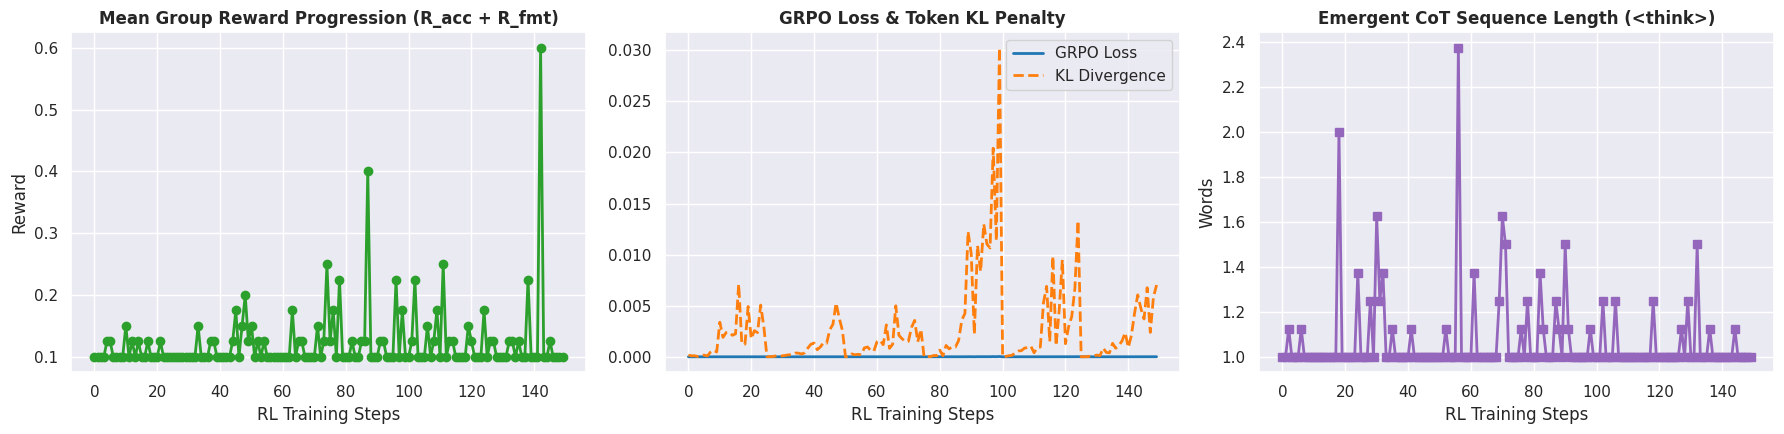

In [23]:
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Plot 1: Mean Group Reward Curve
axes[0].plot(history["step"], history["mean_reward"], color='tab:green', linewidth=2, marker='o')
axes[0].set_title('Mean Group Reward Progression (R_acc + R_fmt)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('RL Training Steps')
axes[0].set_ylabel('Reward')

# Plot 2: GRPO Loss & KL Divergence
axes[1].plot(history["step"], history["grpo_loss"], color='tab:blue', linewidth=2, label='GRPO Loss')
axes[1].plot(history["step"], history["mean_kl"], color='tab:orange', linewidth=2, linestyle='--', label='KL Divergence')
axes[1].set_title('GRPO Loss & Token KL Penalty', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RL Training Steps')
axes[1].legend()

# Plot 3: Thinking Length Expansion
axes[2].plot(history["step"], history["avg_thinking_length"], color='tab:purple', linewidth=2, marker='s')
axes[2].set_title('Emergent CoT Sequence Length (<think>)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('RL Training Steps')
axes[2].set_ylabel('Words')

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# Inference: Inspect Raw Model Output (Think/Answer Tokens)
# =====================================================================

test_samples = [dataset[i] for i in range(3)]

policy_model.eval()
for sample in test_samples:
    prompt_text = sample["prompt"]
    ground_truth = sample["ground_truth"]

    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        gen_out = policy_model.generate(
            **inputs,
            max_new_tokens=MAX_GEN_TOKENS,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # Keep special tokens so <think>/<answer> boundaries are visible
    completion_text = tokenizer.decode(gen_out[0][prompt_len:], skip_special_tokens=False)

    print("=" * 80)
    print(f"Input Prompt   : {sample['expression']}")
    print(f"Ground Truth   : {ground_truth}")
    print(f"Raw Model Output:\n<think>{completion_text}")


## level 2

## Stage 2: Language consistency reward

In the second stage of the DeepSeek-R1 pipeline, the authors address a major failure mode of pure RL: language mixing inside the reasoning trace.

When a model is rewarded only for final-answer accuracy, it can sometimes switch languages or mix tokens when it finds a shortcut that lowers entropy. To prevent this, DeepSeek introduces a language consistency reward.

### Reward definition

The language reward is defined as:

$$
R_{\text{language}} = \frac{\text{Count}(\text{Words}_{\text{target language}})}{\text{Total Count}(\text{Words in Completion})}
$$

The total reward in Stage 2 becomes:

$$
R_{\text{total}} = R_{\text{accuracy}} + R_{\text{format}} + \beta \cdot R_{\text{language}}
$$

If the prompt is written in English, any non-English tokens generated inside the reasoning trace receive a penalty, which encourages language purity without sacrificing reasoning quality.

In [4]:
"""
2_language_reward.py
--------------------
Implementation of Stage 2 Language Consistency Reward (Equation 7 in DeepSeek-R1 paper).
Calculates the proportion of completion tokens that match the target prompt language
to prevent language mixing inside reasoning (<think>) blocks.
"""

import re
from typing import Dict, Any


class LanguageConsistencyReward:
    def __init__(self, target_lang: str = "en", penalty_weight: float = 0.2):
        """
        :param target_lang: Expected language code ('en' for English).
        :param penalty_weight: Weight coefficient (beta) for language consistency reward.
        """
        self.target_lang = target_lang
        self.penalty_weight = penalty_weight

    def _is_english_word(self, word: str) -> bool:
        """
        Checks if a token contains standard Latin characters / English punctuation.
        """
        # Matches ASCII printable characters common in English reasoning
        return bool(re.match(r"^[a-zA-Z0-9\s\.\,\!\?\-\_\+\*\/\=\<\>\(\)\[\]\{\}\'\"\_]+$", word))

    def compute_language_reward(self, completion_text: str) -> Dict[str, Any]:
        """
        Calculates language purity score across completion tokens.
        Equation 7: R_lang = (Target Language Words) / (Total Words)
        """
        # Extract words/tokens
        tokens = completion_text.strip().split()
        if not tokens:
            return {"r_lang": 0.0, "purity_ratio": 1.0}

        valid_count = 0
        for token in tokens:
            if self._is_english_word(token):
                valid_count += 1

        purity_ratio = valid_count / len(tokens)
        
        # Soft penalty applied if purity drops below threshold
        r_lang = self.penalty_weight * purity_ratio if purity_ratio < 0.95 else self.penalty_weight

        return {
            "r_lang": round(r_lang, 4),
            "purity_ratio": round(purity_ratio, 4),
            "total_tokens": len(tokens),
            "valid_tokens": valid_count
        }


# =====================================================================
# Standalone Unit Test Suite
# =====================================================================
if __name__ == "__main__":
    print("=== Running Unit Test Suite for 2_language_reward.py ===")
    
    evaluator = LanguageConsistencyReward(target_lang="en", penalty_weight=0.2)

    # Test 1: Clean English Reasoning
    clean_text = "<think> Let us multiply 14 by 3 to get 42, then subtract 12. </think> <answer> 30 </answer>"
    res1 = evaluator.compute_language_reward(clean_text)
    print(f"Test 1 [Clean English]: Purity = {res1['purity_ratio']:.2f} | R_lang = {res1['r_lang']}")
    assert res1["purity_ratio"] == 1.0, "Clean English test failed"

    # Test 2: Mixed Language (English + Chinese characters)
    mixed_text = "<think> 我们首先计算 14*3=42, then subtract 12 to get answer. </think> <answer> 30 </answer>"
    res2 = evaluator.compute_language_reward(mixed_text)
    print(f"Test 2 [Mixed Language]: Purity = {res2['purity_ratio']:.2f} | R_lang = {res2['r_lang']}")
    assert res2["purity_ratio"] < 0.95, "Mixed language test failed to detect non-target tokens"

    print("\nLanguage Consistency Reward Module Successfully Verified!")

=== Running Unit Test Suite for 2_language_reward.py ===
Test 1 [Clean English]: Purity = 1.00 | R_lang = 0.2
Test 2 [Mixed Language]: Purity = 0.92 | R_lang = 0.1846

Language Consistency Reward Module Successfully Verified!


## Stage 3: Rejection sampling and SFT dataset curation

Once the Stage 2 RL checkpoint converges, the next step is to use that trained policy to generate multiple candidate trajectories and keep only the highest-quality ones.

This produces a filtered dataset for supervised fine-tuning.


## Rejection sampling flow

1. Start with a candidate prompt.
2. Generate $N$ rollout trajectories.
3. Evaluate each trajectory for:
   - math accuracy,
   - format compliance,
   - language consistency.
4. Keep the accepted trajectories and discard the rest.
5. Save the accepted ones to a JSONL dataset for SFT.

```text
Prompt → Generate candidates → Evaluate → Keep/Reject → Save JSONL
```

## Rejection sampler

This module integrates the reward engine and language consistency evaluator to generate, score, and export clean trajectories as a JSONL dataset for SFT.

In [8]:
"""
2_rejection_sampler.py
----------------------
Implements Stage 3 Rejection Sampling from the DeepSeek-R1 multi-stage pipeline.
Generates candidate completions from an RL checkpoint, filters them via rule-based 
verifiers & language consistency checks, and exports clean SFT training data.
"""

import json
import torch
import torch.nn.functional as F
from typing import List, Dict, Any
from transformers import AutoTokenizer, AutoModelForCausalLM

# Import custom reward modules
from reward_engine import R1ZeroRewardEngine


class RejectionSampler:
    def __init__(
        self,
        model=None,
        tokenizer=None,
        model_id: str = "HuggingFaceTB/SmolLM2-135M-Instruct",
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        self.device = device
        
        # Use existing policy model if passed, else load from hub
        if model is not None and tokenizer is not None:
            print("[Rejection Sampler] Using existing RL-trained policy model instance.")
            self.model = model
            self.tokenizer = tokenizer
        else:
            print(f"[Rejection Sampler] Loading Model & Tokenizer: {model_id} on {device}...")
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            if self.tokenizer.pad_token_id is None:
                self.tokenizer.pad_token = self.tokenizer.eos_token
                self.tokenizer.pad_token_id = self.tokenizer.eos_token_id

            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype=torch.float32
            ).to(self.device)
            
        self.model.eval()
        self.reward_engine = R1ZeroRewardEngine(format_weight=0.3)
        self.lang_evaluator = LanguageConsistencyReward(penalty_weight=0.2)

    def sample_and_filter(
        self,
        prompt: str,
        ground_truth: str,
        num_candidates: int = 8,  # Increased candidate pool size
        max_tokens: int = 128,
        temperature: float = 1.0   # Higher exploration temperature
    ) -> List[Dict[str, Any]]:
        
        prompt_inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
        prompt_ids = prompt_inputs["input_ids"]
        prompt_mask = prompt_inputs["attention_mask"]
        prompt_len = prompt_ids.shape[1]

        expanded_ids = prompt_ids.repeat(num_candidates, 1)
        expanded_mask = prompt_mask.repeat(num_candidates, 1)

        with torch.no_grad():
            outputs = self.model.generate(
                expanded_ids,
                attention_mask=expanded_mask,
                max_new_tokens=max_tokens,
                do_sample=True,
                temperature=temperature,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id
            )

        accepted_trajectories = []

        for i in range(num_candidates):
            comp_ids = outputs[i, prompt_len:]
            raw_comp = self.tokenizer.decode(comp_ids, skip_special_tokens=False)
            
            # Reconstruction envelope
            eval_text = "<think>" + raw_comp if not raw_comp.startswith("<think>") else raw_comp

            # Compute Rewards
            res_eval = self.reward_engine.compute_reward(eval_text, ground_truth)
            res_lang = self.lang_evaluator.compute_language_reward(raw_comp)

            # Filtering logic: accepts if math is correct and format partial credit >= 0.1
            is_valid_format = res_eval["r_fmt"] >= 0.1
            is_correct_math = res_eval["is_correct"]
            is_clean_lang = res_lang["purity_ratio"] >= 0.80

            if is_correct_math and is_valid_format and is_clean_lang:
                accepted_trajectories.append({
                    "prompt": prompt,
                    "ground_truth": ground_truth,
                    "generated_completion": eval_text,
                    "metrics": {
                        "total_reward": res_eval["total_reward"],
                        "r_acc": res_eval["r_acc"],
                        "r_fmt": res_eval["r_fmt"],
                        "lang_purity": res_lang["purity_ratio"]
                    }
                })

        return accepted_trajectories

    def export_dataset(self, data_pairs: List[Dict[str, str]], output_path: str = "distilled_sft_dataset.jsonl"):
        """
        Executes rejection sampling over a dataset of questions and saves accepted trajectories to JSONL.
        """
        print(f"\n=== Starting Rejection Sampling Dataset Generation ===")
        all_accepted = []

        for idx, item in enumerate(data_pairs):
            accepted = self.sample_and_filter(
                prompt=item["prompt"],
                ground_truth=item["ground_truth"],
                num_candidates=6,
                temperature=0.8
            )
            print(f"Prompt {idx+1}/{len(data_pairs)}: Generated 6 Candidates -> Accepted {len(accepted)} High-Quality Trajectories")
            all_accepted.extend(accepted)

        # Write to JSONL
        with open(output_path, "w", encoding="utf-8") as f:
            for record in all_accepted:
                f.write(json.dumps(record) + "\n")

        print(f"\nSuccessfully saved {len(all_accepted)} distilled SFT trajectories to '{output_path}'!")


# =====================================================================
# Standalone Test Execution
# =====================================================================
if __name__ == "__main__":
    sampler = RejectionSampler()

    test_prompts = [
        {"prompt": "User: Solve 4*3+5= Assistant: <think>", "ground_truth": "17"},
        {"prompt": "User: Solve 6*2-4= Assistant: <think>", "ground_truth": "8"},
        {"prompt": "User: Solve 8*4-2= Assistant: <think>", "ground_truth": "30"},
    ]

    sampler.export_dataset(test_prompts, output_path="sample_rejection_sft.jsonl")

[Rejection Sampler] Loading Model & Tokenizer: HuggingFaceTB/SmolLM2-135M-Instruct on cpu...

=== Starting Rejection Sampling Dataset Generation ===
Prompt 1/3: Generated 6 Candidates -> Accepted 0 High-Quality Trajectories
Prompt 2/3: Generated 6 Candidates -> Accepted 0 High-Quality Trajectories
Prompt 3/3: Generated 6 Candidates -> Accepted 0 High-Quality Trajectories

Successfully saved 0 distilled SFT trajectories to 'sample_rejection_sft.jsonl'!


## Baseline comparison run

This run is intended to evaluate the system against the base model rather than the trained model.

Because the base model is not aligned to the expected reasoning and formatting behavior, the acceptance rate is expected to be very low or near zero.